In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '../assets/dataset-b/employee_reviews_indeed_latest_cleaned_labeled_with_rating.csv'

df_raw = pd.read_csv(file_path)

In [2]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7024 entries, 0 to 7023
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   company      7024 non-null   object 
 1   review_date  7024 non-null   object 
 2   rating       7024 non-null   float64
 3   clean_text   7024 non-null   object 
 4   sentiment    7024 non-null   object 
dtypes: float64(1), object(4)
memory usage: 274.5+ KB


In [17]:
# Pre-processing: Convert only the review_date to datetime
df_raw['review_date'] = pd.to_datetime(df_raw['review_date'])

C:\Users\sheng\AppData\Local\Temp\ipykernel_26016\1094186578.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='rating', data=df_raw, palette='viridis')


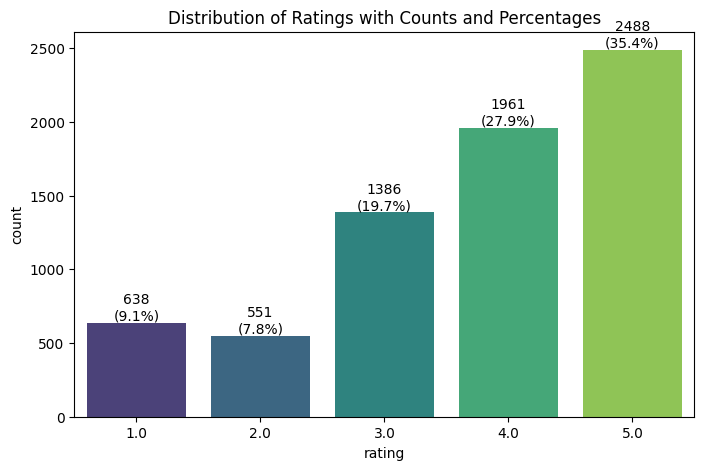

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='rating', data=df_raw, palette='viridis')

# Calculate percentages for the labels
total = len(df_raw)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{int(y)}\n({percentage})', (x, y), ha='center', va='bottom')
plt.title('Distribution of Ratings with Counts and Percentages')
plt.show()

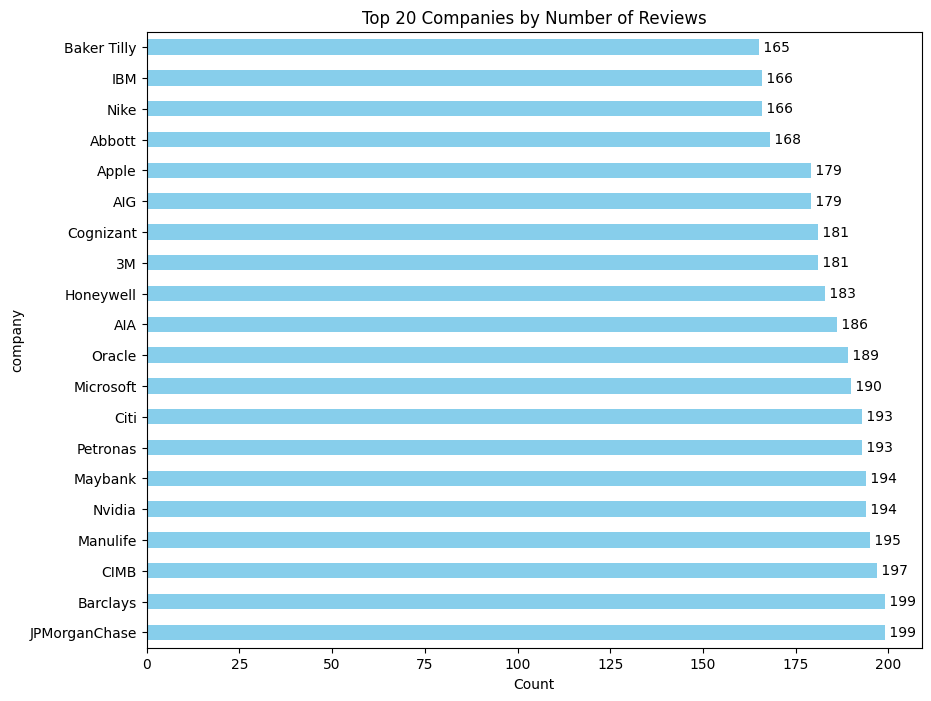

In [8]:
# --- Variable: company (Categorical) ---
plt.figure(figsize=(10, 8))
ax = df_raw['company'].value_counts().head(20).plot(
    kind='barh', color='skyblue'
)
# Add numbers to each bar
for i, v in enumerate(df_raw['company'].value_counts().head(20)):
    ax.text(v, i, f' {v}', va='center')
plt.title('Top 20 Companies by Number of Reviews')
plt.xlabel('Count')

plt.show()

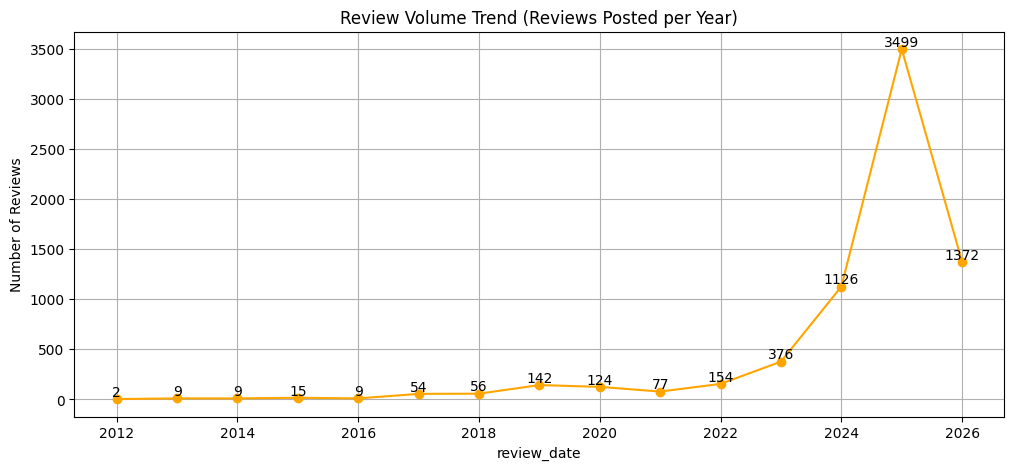

In [10]:
# --- Variable: review_date (Time Series) ---
plt.figure(figsize=(12, 5))
# Prepare data
year_counts = df_raw['review_date'].dt.year.value_counts().sort_index()
# Plot
ax = year_counts.plot(kind='line', marker='o', color='orange')
# Add numbers on each point
for x, y in zip(year_counts.index, year_counts.values):
    ax.text(x, y, str(y), ha='center', va='bottom')
plt.title('Review Volume Trend (Reviews Posted per Year)')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.show()

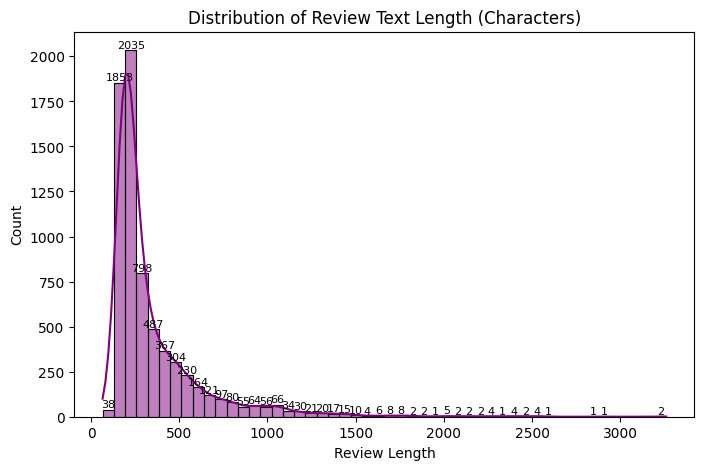

In [ ]:
# --- Variable: clean_text (Text Analysis) ---
# Analyze the length of the reviews 
# Create review length
df_raw['review_length'] = df_raw['clean_text'].apply(lambda x: len(str(x)))
plt.figure(figsize=(8, 5))
ax = sns.histplot(df_raw['review_length'], bins=50, kde=True, color='purple')
# Add numbers on each bar (bin)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # avoid showing 0
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8)

plt.title('Distribution of Review Text Length (Characters)')
plt.xlabel('Review Length')
plt.show()

C:\Users\sheng\AppData\Local\Temp\ipykernel_26016\992808119.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='rating', y='company', data=data, palette='Set3')


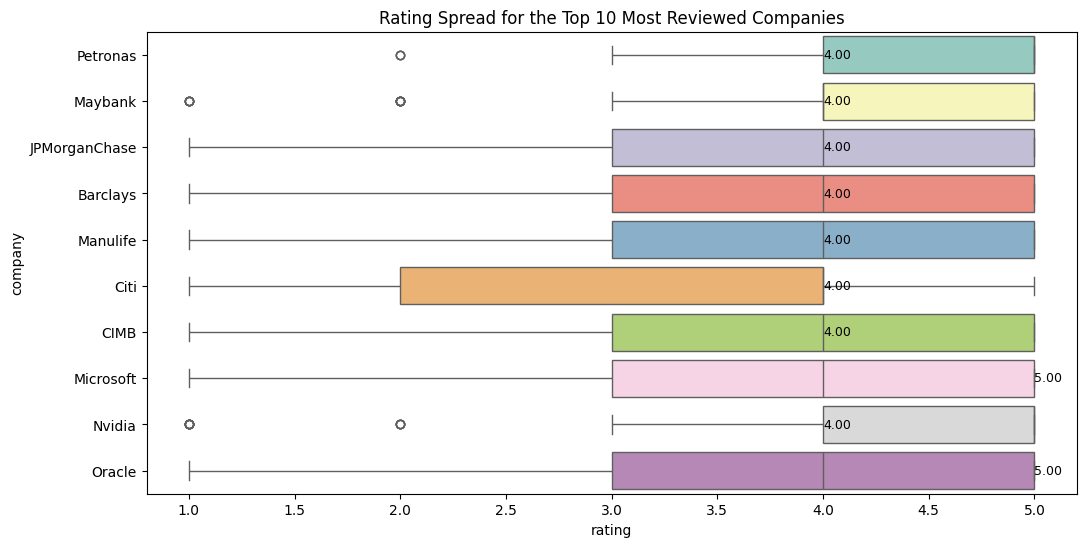

In [ ]:
top_10_cos = df_raw['company'].value_counts().nlargest(10).index
data = df_raw[df_raw['company'].isin(top_10_cos)]
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='rating', y='company', data=data, palette='Set3')
medians = data.groupby('company')['rating'].median()
for i, company in enumerate(medians.index):
    ax.text(medians[company], i, f'{medians[company]:.2f}',
            va='center', ha='left', fontsize=9, color='black')

plt.title('Rating Spread for the Top 10 Most Reviewed Companies')
plt.show()